## Tadpole Plot in Image Log

A **tadpole plot** is used in image log interpretation to show the **dip angle** and **dip direction (azimuth)** of geological features such as bedding planes, fractures, and faults with depth.

### Structure:
- **Dot (head):** Represents the feature at a specific depth  
- **Tail:** Points in the dip direction  
- **Tail length / position:** May indicate dip magnitude (depends on software)

### Uses:
- Identify bedding trends  
- Detect fractures and faults  
- Analyze structural changes with depth  
- Support borehole image interpretation

### Simple Definition:
A tadpole plot is a graphical depth-based display of planar feature orientation derived from borehole image logs.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
picks = pd.read_csv('/home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/notebooks/day-50/tadpole_data.csv')
picks.tail()

,id,depth,dip_angle,dip_azimuth,feature_type,auto_picked
196,197,7523.940711,60.728348,169.982738,Bedding,1
197,198,7524.622972,50.486866,180.037274,Bedding,1
198,199,7525.306662,39.458326,149.953368,Bedding,1
199,200,7525.990072,4.635411,229.186406,Bedding,1
200,201,7526.671341,75.459460,159.984171,Bedding,1


In [11]:
beds = picks[(picks['feature_type'] == 'Bedding')].copy()
# fractures = picks[(picks['type'] == 'Conductive, HC') | (picks['type'] == 'Conductive, LC')].copy()
# mudlog = pd.read_csv('1_pre-processed mudlog.csv')

# these imports and boolean statements are from the second notebook, 
# so we have not included the usual checks
beds

,id,depth,dip_angle,dip_azimuth,feature_type,auto_picked
0,1,7390.006537,75.495927,300.006834,Bedding,1
1,2,7390.690127,14.600220,89.930451,Bedding,1
2,3,7391.372963,39.497226,170.006707,Bedding,1
3,4,7392.056918,14.603927,169.886849,Bedding,1
4,5,7392.739854,39.563595,349.984576,Bedding,1
...,...,...,...,...,...,...
196,197,7523.940711,60.728348,169.982738,Bedding,1
197,198,7524.622972,50.486866,180.037274,Bedding,1
198,199,7525.306662,39.458326,149.953368,Bedding,1
199,200,7525.990072,4.635411,229.186406,Bedding,1


In [9]:


def tail_endpoint(depths, dipazs, dips, tail_length, fig_x_width, fig_y_width, ylim_max, xlim_max):
    """
    Calculate and return the x and y coordinates for the tadpole tail endpoints.

    Parameters:
    - depths (list or array): List of depths for each data point.
    - dipazs (list or array): List of dip azimuths for each data point.
    - dips (list or array): List of dip angles for each data point.
    - tail_length (float): The length of the tail as a decimal percentage of the axis scale.
    - fig_x_width (float): Width of the figure in inches.
    - fig_y_width (float): Height of the figure in inches.
    - ylim_max (float): Maximum depth of the plot.
    - xlim_max (float): Maximum dip of the plot.

    Returns:
    - tuple: A tuple containing two lists, the first with x coordinates of tail endpoints
             and the second with y coordinates of tail endpoints.
    
    Notes:
    - fig_x_width and fig_y_width are the values passed in when making the figure (fig_size=(x,y))
      and these widths determine the aspect ratio of the plot (n pixels in each direction).
    - fig_ratio is a multiplier on y or x axis tail length depending on which plot axis has more pixels
    """
    tail_endpoints_y = []
    tail_endpoints_x = []

    for depth, dipaz, dip in zip(depths, dipazs, dips):

        if fig_x_width < fig_y_width:
            fig_ratio = fig_y_width / fig_x_width # this is the ratio of y to x inches (pixels)
            tail_endpoints_y.append(depth - (ylim_max * tail_length) * math.cos(math.radians(dipaz)))
            tail_endpoints_x.append(dip + (xlim_max * tail_length * fig_ratio) * math.sin(math.radians(dipaz)))

        else:
            fig_ratio = fig_x_width / fig_y_width
            tail_endpoints_y.append(depth - (ylim_max * tail_length * fig_ratio) * math.cos(math.radians(dipaz)))
            tail_endpoints_x.append(dip + (xlim_max * tail_length) * math.sin(math.radians(dipaz)))
    
    return tail_endpoints_x, tail_endpoints_y



(7526.671341, 7390.006537)

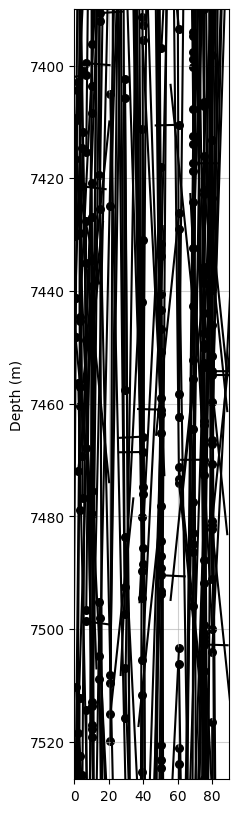

In [13]:
# The tadpole tails are different lengths when I use the "real" data
# Tadpole tails are too long on the y axis and too short on the x axis
# I can't see why this would be the case - the function is the same and the variables passed in are also the same
import math
dips = beds['dip_angle'].values
dipazs = beds['dip_azimuth'].values
depths = beds['depth'].values

# Log length
log_top = min(depths)
log_bot = max(depths)

# Fix the aspect ratio of the plot
fig_x_width = 2 
fig_y_width = 10

# make the figure
fig, ax = plt.subplots(1,1,figsize=(fig_x_width,fig_y_width))

# fix the axis scales
xlim_max = 90
ylim_max = log_bot

# Calculate tail endpoints
tail_endpoints_y = []
tail_endpoints_x = []

tail_length = 0.03 # as a % of the axis scale

tail_endpoints_x_test, tail_endpoints_y_test = tail_endpoint(
    depths, dipazs, dips, tail_length, fig_x_width, fig_y_width, ylim_max, xlim_max
    )

# Plot the tadpoles

for depth, dip, tail_endpoint_x, tail_endpoint_y in zip(depths, dips, tail_endpoints_x_test, tail_endpoints_y_test):
    
        # plot the head
    
        ax.scatter(
            dip,
            depth,
            s = 30,
            color = 'k',
        )
    
        # plot the tail
    
        ax.plot(
            [dip, tail_endpoint_x],
            [depth, tail_endpoint_y],
            color = 'k'
        )

# Format plot

ax.xaxis.set_ticks([0,20,40,60,80,])
ax.set_xlim(0,90)
ax.set_ylabel('Depth (m)')
ax.grid(alpha=0.6)
ax.set_ylim(log_bot, log_top)

